In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import svd, orth, qr
from scipy.optimize import curve_fit
from numpy import sin, cos, pi
cmap = plt.cm.plasma
from scipy.ndimage import gaussian_filter1d
from scipy.signal import wiener
from scipy.signal import wiener, butter, freqs, convolve, freqz
from scipy.fft import fft, ifft, fftshift, ifftshift, fftfreq
from scipy.interpolate import (RegularGridInterpolator, RectBivariateSpline,
                               interpn, griddata, Rbf, interp1d, interp2d)
import cv2
from scipy.signal import convolve2d as conv2
from skimage import color, data, restoration
from smooth_POD_ROM.reduced_order_model import pulse, delta_n_width, train_ROM, L2_error, zielfunktion
from smooth_POD_ROM.pre_processing import convolve_f, gaussian_f, gaussian, smoothen
from smooth_POD_ROM.post_processing import richardson_lucy, post_process
from scipy.optimize import minimize

In [2]:
import matplotlib.pyplot as plt
import matplotlib as mpl
page_width_pt = 455.24
pt2in = 0.01389 
pt2cm = 0.0352777778
cm2in = 1/2.54
page_width_cm = 13.70499
# TODO: work with textwidth
plot_width_in = page_width_pt*pt2in/2
page_width_in = page_width_cm*cm2in
print(plot_width_in/cm2in)

fs = 10
fs_lbl = 6
plt.rcParams["figure.figsize"] = (plot_width_in, plot_width_in/1.61803398875)
plt.rcParams["figure.autolayout"] = True
plt.rcParams['font.size'] = fs
plt.rcParams['axes.titlesize'] = fs
plt.rcParams['axes.labelsize'] = fs
plt.rcParams['xtick.labelsize'] = fs
plt.rcParams['ytick.labelsize'] = fs
plt.rcParams['legend.labelspacing'] = 0.0
plt.rcParams['legend.fontsize'] = fs_lbl
plt.rcParams['legend.handlelength'] = 2.0

plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
mpl.rc('text', usetex=True)
mpl.rc('font', family='serif', size=fs, serif='Computer Modern Roman')
pth = "../Plots/"

markevery = 40

8.030570172000001


In [129]:
m, n = 1500, 10

x = np.linspace(0, 1, m, endpoint=False)
mu_val_ = x.copy()[::4]

shape = (m,)
clip = True
n_iter = 200

NN = np.arange(3, 150, 2)
n_test = 9
sigma_opt = 1/(NN*3)
c_opt = 1/(NN/50)*0 + 1.3


In [130]:
eROM = np.zeros_like(NN, dtype=np.float64)
esROM = np.zeros_like(NN, dtype=np.float64)
esROMs100 = np.zeros_like(NN, dtype=np.float64)
esROMs250 = np.zeros_like(NN, dtype=np.float64)
esROMs50 = np.zeros_like(NN, dtype=np.float64)


print("sigma", "c", "mean_ROM", "mean_sROM", "mean_sROMs", "improvement")

for i, n in enumerate(NN):
    print(n)
    rank = n

    # generate training data:
    X_train = np.empty((m, n))
    mu_train = np.linspace(0, 1, n, endpoint=True)[:, None]#
    for j, mu_j in enumerate(mu_train):
        X_train[:, j] = pulse(x, mu_j)
    # validation data:
#     interpolatable = (mu_train[0]<mu_val_) & (mu_val_<mu_train[-1])
#     mu_val = mu_val_[interpolatable][:, None]
#     X_val = np.empty((m, len(mu_val)))
#     for j, mu_j in enumerate(mu_val):
#         X_val[:, j] = pulse(x, mu_j)
    # generate test data
    n1 = n//2
    
    mu_test = np.linspace(mu_train[n1, 0], mu_train[n1+1, 0], n_test, endpoint=False)[:, None]
    X_test = np.empty((m, n_test))
    for j, mu_j in enumerate(mu_test):
        X_test[:, j] = pulse(x, mu_j)


    # optimize using test set
    x0 = np.array([sigma_opt[i], c_opt[i]])
    zf =  lambda params: zielfunktion(params, x, mu_train, X_train, mu_test, X_test, rank, shape, n_iter)[0]
    #res = minimize(zf, x0, method='nelder-mead', bounds=[(0, 1), (-1, 10)], options={'disp': True, "fatol": 1e-2})
    #res = minimize(zf, x0, method='Powell', bounds=[(0, 1), (-1, 10)], options={'disp': True, "fatol": 1e-2})
    #res = minimize(zf, x0, method='BFGS', options={'disp': True, "eps": np.array([.001, 0.1]), "maxiter": 50})
    #res = minimize(zf, x0, method='COBYLA', options={'disp': True, "rhobeg": np.array([.025, 0.5]), "maxiter": 50})
    res = minimize(zf, x0, method='SLSQP', bounds=[(0.001, 10*sigma_opt[i]), (-1, 10*c_opt[i])],
                   options={'disp': True, "eps": np.array([.0005, 0.05]), "maxiter": 25, "ftol": 0.0005})
#     res = minimize(zf, x0, method='trust-exact', bounds=[(0.001, 10*sigma_opt[i]), (-1, 10*c_opt[i])],
#                options={'disp': True, "eps": np.array([.0005, 0.05]), "maxiter": 25, "ftol": 0.0005, "max_trust_radius": np.array([.0005, 0.05])})
#     bounds = Bounds([0.001, -1.], [10*sigma_opt[i], 10*c_opt[i]])
#     result = direct(zf, bounds)
    print(res["message"])
    
    sigma_opt[i], c_opt[i] = res["x"]
    # TODO: run with mu_val?
    _i, _R, _sR, _sRs = zielfunktion(res["x"], x, mu_train, X_train, mu_test, X_test, rank, shape, 100)
    eROM[i] = np.mean(L2_error(_R, X_test))
    esROM[i] = np.mean(L2_error(_sR, X_test))
    esROMs100[i] = np.mean(L2_error(_sRs, X_test))
    _i, _R, _sR, _sRs = zielfunktion(res["x"], x, mu_train, X_train, mu_test, X_test, rank, shape, 250)
    esROMs250[i] = np.mean(L2_error(_sRs, X_test))
    _i, _R, _sR, _sRs = zielfunktion(res["x"], x, mu_train, X_train, mu_test, X_test, rank, shape, 50)
    esROMs50[i] = np.mean(L2_error(_sRs, X_test))
    print(eROM[i], esROM[i], esROMs100[i], esROMs250[i])


sigma c mean_ROM mean_sROM mean_sROMs improvement
3
0.11111111, 1.30000000, 0.26814362, 0.25800616, 0.28429893, 6.0249 %
0.11161111, 1.30000000, 0.26814362, 0.25800095, 0.28424896, 6.0062 %
0.11111111, 1.35000000, 0.26814362, 0.25800616, 0.28430874, 6.0285 %
1.11111111, 1.22679577, 0.26814362, 0.26220219, 0.26220219, -2.2158 %
1.11061111, 1.22679577, 0.26814362, 0.26220219, 0.26220219, -2.2158 %
1.11111111, 1.27679577, 0.26814362, 0.26220219, 0.26220219, -2.2158 %
Optimization terminated successfully    (Exit mode 0)
            Current function value: -2.2157652389691265
            Iterations: 2
            Function evaluations: 6
            Gradient evaluations: 2
Optimization terminated successfully
1.11111111, 1.22679577, 0.26814362, 0.26220219, 0.26220219, -2.2158 %
1.11111111, 1.22679577, 0.26814362, 0.26220219, 0.26220219, -2.2158 %
1.11111111, 1.22679577, 0.26814362, 0.26220219, 0.26220219, -2.2158 %
0.26814362355019766 0.2622021903510274 0.262202190349813 0.2622021903487894


0.09080481, 5.49454252, 0.23941255, 0.22573732, 0.06838189, -71.4376 %
0.00100000, 9.81202942, 0.23941255, 0.24041560, 0.25037559, 4.5791 %
0.08182433, 5.88129121, 0.23941255, 0.22290204, 0.06415470, -73.2033 %
0.08232433, 5.88129121, 0.23941255, 0.22306172, 0.06445913, -73.0761 %
0.08182433, 5.93129121, 0.23941255, 0.22290204, 0.06433503, -73.1280 %
0.00100000, 9.98908681, 0.23941255, 0.24041560, 0.25052555, 4.6418 %
0.07374190, 6.29207077, 0.23941255, 0.22032471, 0.06074743, -74.6265 %
0.07424190, 6.29207077, 0.23941255, 0.22048277, 0.06102628, -74.5100 %
0.07374190, 6.34207077, 0.23941255, 0.22032471, 0.06089452, -74.5650 %
0.00100000, 10.05853903, 0.23941255, 0.24041560, 0.25058579, 4.6669 %
0.06646771, 6.66871760, 0.23941255, 0.21808849, 0.05834396, -75.6304 %
0.06696771, 6.66871760, 0.23941255, 0.21823689, 0.05869496, -75.4838 %
0.06646771, 6.71871760, 0.23941255, 0.21808849, 0.05851339, -75.5596 %
0.00100000, 10.02946675, 0.23941255, 0.24041560, 0.25055885, 4.6557 %
0.05992093, 

0.02775408, 9.86272388, 0.21184821, 0.19324565, 0.04832772, -77.1876 %
0.03042948, 9.54899627, 0.21184821, 0.19311468, 0.04525782, -78.6367 %
0.03063511, 9.52488369, 0.21184821, 0.19311980, 0.04521250, -78.6581 %
0.03113511, 9.52488369, 0.21184821, 0.19314084, 0.04535778, -78.5895 %
0.03063511, 9.57488369, 0.21184821, 0.19311980, 0.04524473, -78.6429 %
0.00337465, 13.00000000, 0.21184821, 0.21123313, 0.25615607, 20.9149 %
0.02790907, 9.87239532, 0.21184821, 0.19322765, 0.04793777, -77.3716 %
0.03036251, 9.55963486, 0.21184821, 0.19311346, 0.04528736, -78.6227 %
0.03057631, 9.53238021, 0.21184821, 0.19311813, 0.04521662, -78.6561 %
0.03061311, 9.52768904, 0.21184821, 0.19311916, 0.04521329, -78.6577 %
0.03062572, 9.52608051, 0.21184821, 0.19311952, 0.04521273, -78.6580 %
0.03063092, 9.52541770, 0.21184821, 0.19311968, 0.04521258, -78.6580 %
0.03063321, 9.52512659, 0.21184821, 0.19311975, 0.04521253, -78.6581 %
0.03063424, 9.52499511, 0.21184821, 0.19311978, 0.04521251, -78.6581 %
0.0306

0.04386191, 7.50135658, 0.16120289, 0.17762864, 0.04559903, -71.7133 %
0.04436191, 7.50135658, 0.16120289, 0.17818361, 0.04573724, -71.6275 %
0.04386191, 7.55135658, 0.16120289, 0.17762864, 0.04565754, -71.6770 %
0.06637052, -0.99999907, 0.16120289, 0.19978968, 0.16481181, 2.2387 %
0.04611278, 6.65122101, 0.16120289, 0.18011299, 0.04518052, -71.9729 %
0.04661278, 6.65122101, 0.16120289, 0.18065940, 0.04531225, -71.8912 %
0.04611278, 6.70122101, 0.16120289, 0.18011299, 0.04524076, -71.9355 %
0.06634152, -0.99092965, 0.16120289, 0.19976552, 0.16464624, 2.1360 %
0.04813565, 5.88700595, 0.16120289, 0.18230921, 0.04477191, -72.2264 %
0.04863565, 5.88700595, 0.16120289, 0.18284579, 0.04489610, -72.1493 %
0.04813565, 5.93700595, 0.16120289, 0.18230921, 0.04483206, -72.1891 %
0.07101562, -1.00000000, 0.16120289, 0.20351146, 0.16795268, 4.1871 %
0.05042365, 5.19830535, 0.16120289, 0.18474211, 0.04448842, -72.4022 %
0.05092365, 5.19830535, 0.16120289, 0.18526577, 0.04460970, -72.3270 %
0.0504236

0.01960784, 1.30000000, 0.13370245, 0.13251034, 0.12914340, -3.4098 %
0.02010784, 1.30000000, 0.13370245, 0.13311615, 0.12769689, -4.4917 %
0.01960784, 1.35000000, 0.13370245, 0.13251034, 0.12832310, -4.0234 %
0.19607546, 13.00000000, 0.13370245, 0.24611723, 0.23580132, 76.3628 %
0.09621087, 6.37886625, 0.13370245, 0.21789599, 0.07314085, -45.2958 %
0.09671087, 6.37886625, 0.13370245, 0.21816661, 0.07375633, -44.8355 %
0.09621087, 6.42886625, 0.13370245, 0.21789599, 0.07361103, -44.9441 %
0.11003393, -1.00000000, 0.13370245, 0.22458175, 0.18817185, 40.7393 %
0.09837315, 5.22462498, 0.13370245, 0.21904934, 0.06739218, -49.5954 %
0.09887315, 5.22462498, 0.13370245, 0.21930986, 0.06771612, -49.3531 %
0.09837315, 5.27462498, 0.13370245, 0.21904934, 0.06763943, -49.4105 %
0.03359324, 12.73020106, 0.13370245, 0.15314989, 0.04720674, -64.6927 %
0.03409324, 12.73020106, 0.13370245, 0.15394819, 0.04735067, -64.5850 %
0.03359324, 12.78020106, 0.13370245, 0.15314989, 0.04724285, -64.6657 %
0.0304

...

0.00271003, 1.30000000, 0.04903565, 0.04640443, 0.04215870, -14.0244 %
0.00321003, 1.30000000, 0.04903565, 0.04764859, 0.03076246, -37.2651 %
0.00271003, 1.35000000, 0.04903565, 0.04640443, 0.04116630, -16.0482 %
0.00853164, 12.99998850, 0.04903565, 0.06555900, 0.08770928, 78.8684 %
0.00529781, 6.50079520, 0.04903565, 0.05446378, 0.07772184, 58.5007 %
0.00377125, 3.43279302, 0.04903565, 0.04931269, 0.04140441, -15.5626 %
0.00324672, 2.37862748, 0.04903565, 0.04775023, 0.02757532, -43.7647 %
0.00374672, 2.37862748, 0.04903565, 0.04923582, 0.03072414, -37.3433 %
0.00324672, 2.42862748, 0.04903565, 0.04775023, 0.02785797, -43.1883 %
0.00588762, -1.00000000, 0.04903565, 0.05652867, 0.04692141, -4.3116 %
0.00351081, 2.04076474, 0.04903565, 0.04851375, 0.02662258, -45.7077 %
0.00401081, 2.04076474, 0.04903565, 0.05007857, 0.02930571, -40.2359 %
0.00351081, 2.09076474, 0.04903565, 0.04851375, 0.02704073, -44.8550 %
0.00107392, -0.99999991, 0.04903565, 0.04580916, 0.04522337, -7.7745 %
0.00268

0.00150000, 9.86913723, 0.04831018, 0.04443255, 0.03672063, -23.9899 %
0.00100000, 9.91913723, 0.04831018, 0.04517982, 0.02975071, -38.4173 %
0.00100000, 7.94315388, 0.04831018, 0.04517982, 0.03502154, -27.5069 %
0.00100000, 9.62640076, 0.04831018, 0.04517982, 0.02970068, -38.5209 %
0.00100000, 9.74585066, 0.04831018, 0.04517982, 0.02962746, -38.6724 %
0.00150000, 9.74585066, 0.04831018, 0.04443255, 0.03627731, -24.9075 %
0.00100000, 9.79585066, 0.04831018, 0.04517982, 0.02967029, -38.5838 %
0.00117824, 6.54481546, 0.04831018, 0.04480596, 0.03356696, -30.5178 %
0.00101782, 9.42574714, 0.04831018, 0.04513700, 0.02958161, -38.7673 %
0.00151782, 9.42574714, 0.04831018, 0.04442274, 0.03556096, -26.3903 %
0.00101782, 9.47574714, 0.04831018, 0.04513700, 0.02953388, -38.8661 %
0.00100000, 9.68844007, 0.04831018, 0.04517982, 0.02963348, -38.6600 %
0.00100981, 9.54388497, 0.04831018, 0.04515611, 0.02959934, -38.7306 %
0.00101413, 9.48018858, 0.04831018, 0.04514578, 0.02958853, -38.7530 %
0.0010

0.00100000, 2.83898129, 0.04738913, 0.04420274, 0.05732469, 20.9659 %
0.00378532, 1.29267937, 0.04738913, 0.04838497, 0.02303770, -51.3861 %
0.00402310, 1.16067787, 0.04738913, 0.04920539, 0.02290654, -51.6629 %
0.00407582, 1.13140782, 0.04738913, 0.04938985, 0.02288473, -51.7089 %
0.00408946, 1.12383484, 0.04738913, 0.04943771, 0.02287994, -51.7190 %
0.00409327, 1.12171877, 0.04738913, 0.04945109, 0.02287867, -51.7217 %
0.00409436, 1.12111322, 0.04738913, 0.04945492, 0.02287832, -51.7224 %
0.00409468, 1.12093888, 0.04738913, 0.04945602, 0.02287821, -51.7227 %
0.00409477, 1.12088853, 0.04738913, 0.04945634, 0.02287818, -51.7227 %
0.00409479, 1.12087397, 0.04738913, 0.04945643, 0.02287818, -51.7227 %
0.00409480, 1.12086976, 0.04738913, 0.04945646, 0.02287817, -51.7227 %
Optimization terminated successfully    (Exit mode 0)
            Current function value: -51.7227407845111
            Iterations: 4
            Function evaluations: 29
            Gradient evaluations: 4
Optimization 

0.00466862, 1.61538432, 0.04669963, 0.05117037, 0.02677238, -42.6711 %
0.00416862, 1.66538432, 0.04669963, 0.04933447, 0.02360350, -49.4568 %
0.00282697, -0.99999757, 0.04669963, 0.04485733, 0.04040523, -13.4785 %
0.00370387, 0.70941398, 0.04669963, 0.04767645, 0.02904367, -37.8075 %
0.00400750, 1.30130318, 0.04669963, 0.04875242, 0.02122269, -54.5549 %
0.00450750, 1.30130318, 0.04669963, 0.05057524, 0.02185223, -53.2069 %
0.00400750, 1.35130318, 0.04669963, 0.04875242, 0.02134907, -54.2843 %
0.00708831, -1.00000000, 0.04669963, 0.06003921, 0.04846567, 3.7817 %
0.00431558, 1.07117287, 0.04669963, 0.04987027, 0.02087278, -55.3042 %
0.00481558, 1.07117287, 0.04669963, 0.05171494, 0.02135827, -54.2646 %
0.00431558, 1.12117287, 0.04669963, 0.04987027, 0.02097851, -55.0778 %
0.00721115, -1.00000000, 0.04669963, 0.06047532, 0.04875565, 4.4026 %
0.00460514, 0.86405558, 0.04669963, 0.05093560, 0.02092371, -55.1951 %
0.00442487, 0.99300220, 0.04669963, 0.05027109, 0.02081447, -55.4291 %
0.00492

0.00606639, -1.00000000, 0.04517439, 0.05606764, 0.04561461, 0.9745 %
0.00411754, 1.47999882, 0.04517439, 0.04869240, 0.02658336, -41.1539 %
0.00461754, 1.47999882, 0.04517439, 0.05058511, 0.02990372, -33.8038 %
0.00411754, 1.52999882, 0.04517439, 0.04869240, 0.02715821, -39.8814 %
0.00126429, -0.99999959, 0.04517439, 0.04167202, 0.04042281, -10.5183 %
0.00301300, 0.51994984, 0.04517439, 0.04474928, 0.03853465, -14.6980 %
0.00378293, 1.18916144, 0.04517439, 0.04744768, 0.02288992, -49.3299 %
0.00428293, 1.18916144, 0.04517439, 0.04931555, 0.02425926, -46.2986 %
0.00378293, 1.23916144, 0.04517439, 0.04744768, 0.02298263, -49.1246 %
0.00100000, 2.23672238, 0.04517439, 0.04200418, 0.05391982, 19.3593 %
0.00350464, 1.29391753, 0.04517439, 0.04643776, 0.02298150, -49.1271 %
0.00366311, 1.23426563, 0.04517439, 0.04700934, 0.02291482, -49.2747 %
0.00372856, 1.20962902, 0.04517439, 0.04724818, 0.02289790, -49.3122 %
0.00375757, 1.19870840, 0.04517439, 0.04735451, 0.02289302, -49.3230 %
0.00377

In [132]:
# eROM[i] = np.mean(L2_error(_R, X_test))
# esROM[i] = np.mean(L2_error(_sR, X_test))
# esROMs[i] = np.mean(L2_error(_sRs, X_test))
# esROMs
pth = "C:/Users/florianma/OneDrive - Institutt for Energiteknikk/Documents/convolution_paper/data/"
np.save(pth+"eROM200.npy", eROM)
np.save(pth+"esROM200.npy", esROM)
np.save(pth+"esROMs200.npy", esROMs)
np.save(pth+"sigma_opt200.npy", sigma_opt)
np.save(pth+"c_opt200.npy", c_opt)

(0.0, 0.02)

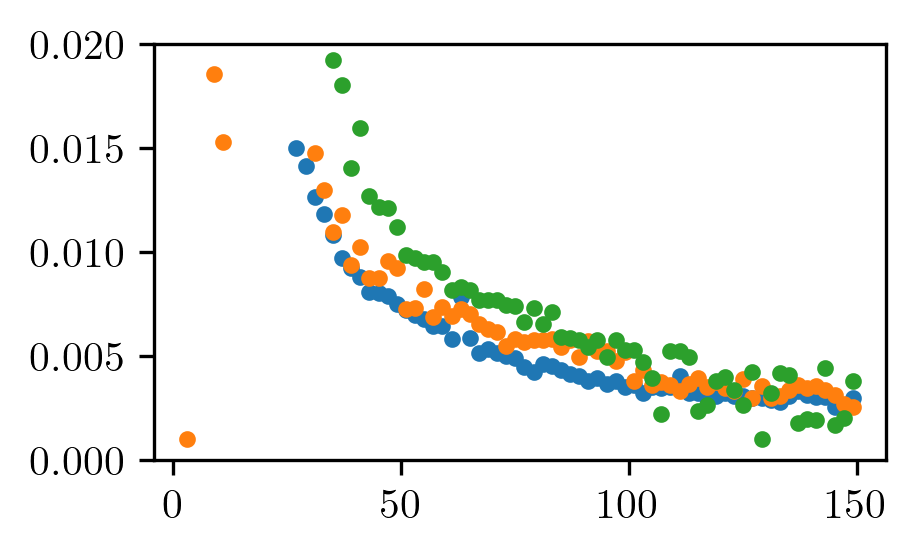

In [134]:
s50 = np.load(pth+"sigma_opt50.npy")
s200 = np.load(pth+"sigma_opt200.npy")
s100 = np.load(pth+"sigma_opt.npy")
plt.plot(NN, s50, "C0.")
plt.plot(NN, s100[::2], "C1.")
plt.plot(NN, s200, "C2.")
plt.ylim(0, 0.02)

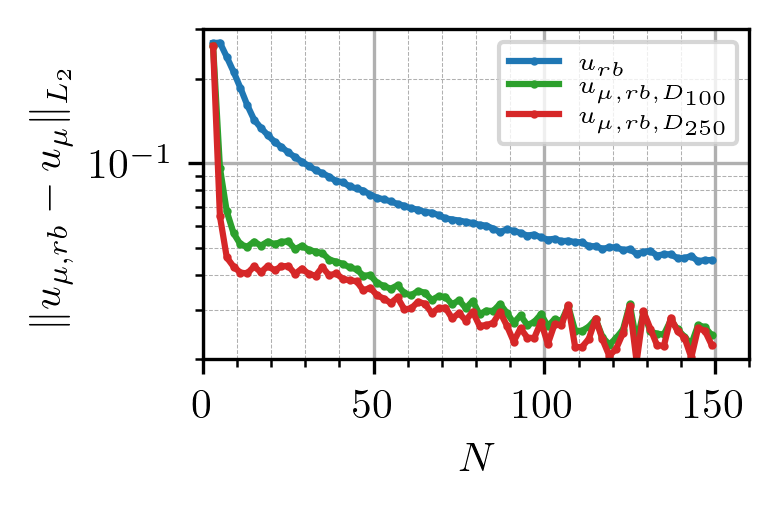

In [135]:
fig, ax = plt.subplots(figsize=(page_width_in/2, page_width_in/3))
plt.plot(NN, eROM, "C0.-", ms=2, label="$u_{rb}$")
#plt.plot(NN, esROM, "C1--", ms=2, label="$u_{rb,S}$")
plt.plot(NN, esROMs100, "C2.-", ms=2, label="$u_{\mu,rb,D_{100}}$")
plt.plot(NN, esROMs250, "C3.-", ms=2, label="$u_{\mu,rb,D_{250}}$")
#plt.plot(mu_val, esROMs2, "C3<-", ms=4, markevery=(20, markevery), label="$u_{rb,D_{100}}$")
plt.legend()
plt.ylabel("$\|u_{\mu,rb}-u_{\mu}\|_{L_2}$")
plt.xlabel("$N$")
# plt.ylim(0, 0.4)
plt.legend()
ax.set_xticks(np.linspace(0, 250, 26, endpoint=True), minor=True)
ax.set_yticks(np.linspace(0, .4, 19, endpoint=True), minor=True)
plt.grid(True, which='minor', linestyle='--', lw=.25)
plt.grid(True, which='major', linestyle='-')
ax.set_yscale('log')
plt.xlim(0, 150)
plt.ylim(2e-2, .3)
plt.show()

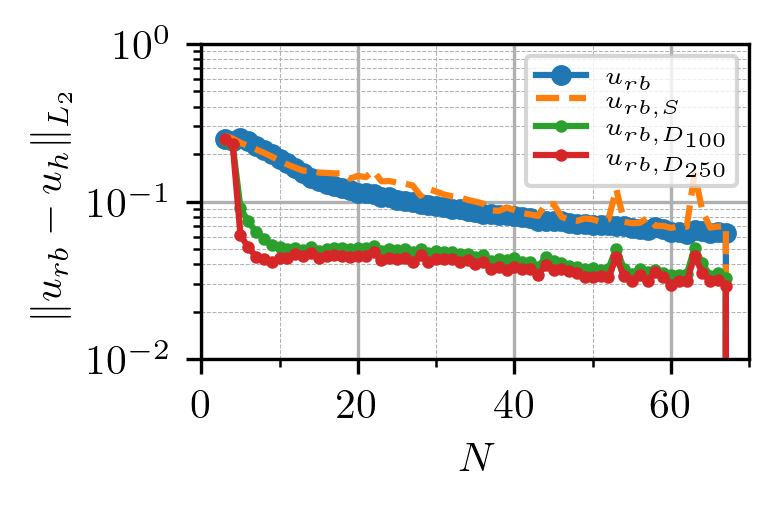

In [42]:

fig, ax = plt.subplots(figsize=(page_width_in/2, page_width_in/3))
plt.plot(NN, eROM, "C0o-", ms=4, label="$u_{rb}$")
plt.plot(NN, esROM, "C1--", ms=4, label="$u_{rb,S}$")
plt.plot(NN, esROMs100, "C2.-", ms=4, label="$u_{rb,D_{100}}$")
plt.plot(NN, esROMs250, "C3.-", ms=4, label="$u_{rb,D_{250}}$")
#plt.plot(mu_val, esROMs2, "C3<-", ms=4, markevery=(20, markevery), label="$u_{rb,D_{100}}$")
plt.legend()
plt.ylabel("$\|u_{rb}-u_h\|_{L_2}$")
plt.xlabel("$N$")
# plt.ylim(0, 0.4)
plt.legend()
ax.set_xticks(np.linspace(0, 250, 26, endpoint=True), minor=True)
ax.set_yticks(np.linspace(0, .4, 19, endpoint=True), minor=True)
plt.grid(True, which='minor', linestyle='--', lw=.25)
plt.grid(True, which='major', linestyle='-')
ax.set_yscale('log')
plt.xlim(0, 70)
plt.ylim(1e-2, 1)
plt.show()

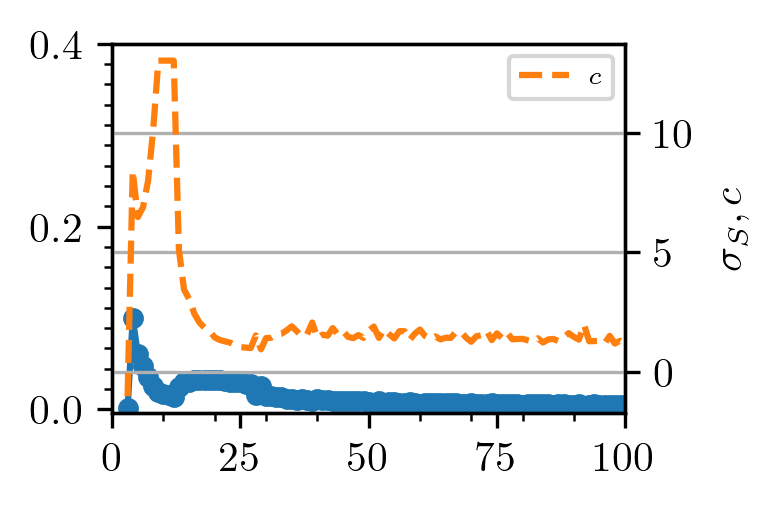

In [87]:

fig, ax = plt.subplots(figsize=(page_width_in/2, page_width_in/3))
ax2 = ax.twinx()
ax.plot(NN, sigma_opt, "C0o-", ms=4, label="$\sigma_S$")
ax2.plot(NN, c_opt, "C1--", ms=4, label="$c$")
#plt.plot(mu_val, esROMs2, "C3<-", ms=4, markevery=(20, markevery), label="$u_{rb,D_{100}}$")
plt.legend()
plt.ylabel("$\sigma_S, c$")
plt.xlabel("$N$")
plt.legend()
ax.set_xticks(np.linspace(0, 250, 26, endpoint=True), minor=True)
ax.set_yticks(np.linspace(0, .4, 19, endpoint=True), minor=True)
plt.grid(True, which='minor', linestyle='--', lw=.25)
plt.grid(True, which='major', linestyle='-')
plt.xlim(0, 100)

plt.show()

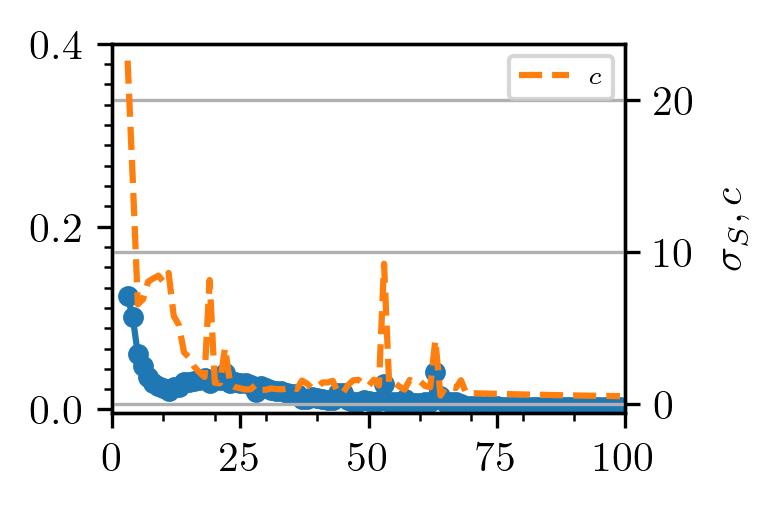

     fun: -45.2071974021247
     jac: array([-2869.73160443,   -19.34289959])
 message: 'Optimization terminated successfully'
    nfev: 100
     nit: 19
    njev: 19
  status: 0
 success: True
       x: array([0.00563976, 1.56181025])


In [35]:

fig, ax = plt.subplots(figsize=(page_width_in/2, page_width_in/3))
ax2 = ax.twinx()
ax.plot(NN, sigma_opt, "C0o-", ms=4, label="$\sigma_S$")
ax2.plot(NN, c_opt, "C1--", ms=4, label="$c$")
#plt.plot(mu_val, esROMs2, "C3<-", ms=4, markevery=(20, markevery), label="$u_{rb,D_{100}}$")
plt.legend()
plt.ylabel("$\sigma_S, c$")
plt.xlabel("$N$")
plt.legend()
ax.set_xticks(np.linspace(0, 250, 26, endpoint=True), minor=True)
ax.set_yticks(np.linspace(0, .4, 19, endpoint=True), minor=True)
plt.grid(True, which='minor', linestyle='--', lw=.25)
plt.grid(True, which='major', linestyle='-')
plt.xlim(0, 100)

plt.show()

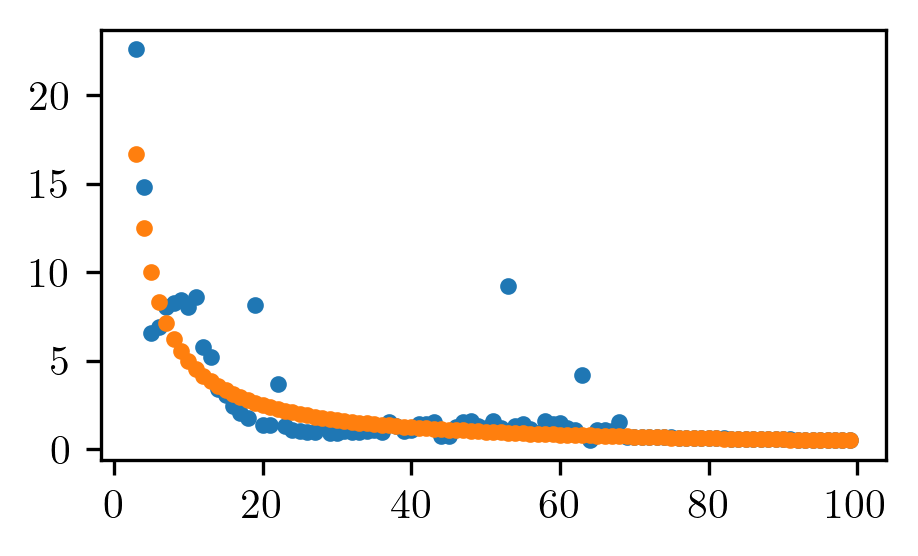

In [56]:
overlap = 0.075*NN / 1
plt.plot(NN, c_opt, "C0.")
plt.plot(NN, 1/(NN/50), "C1.")
#plt.ylim(0, 0.1)

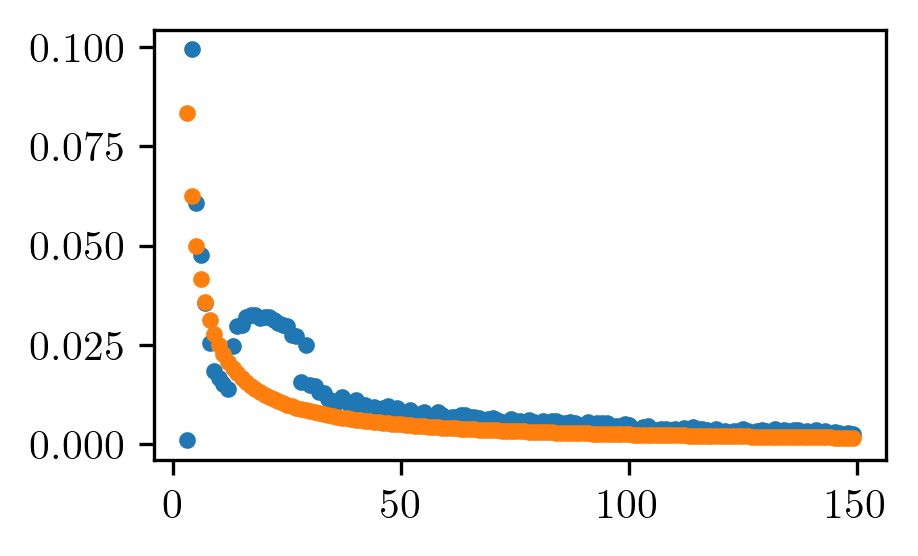

In [101]:
overlap = 0.075*NN / 1
plt.plot(NN, sigma_opt, "C0.")
plt.plot(NN, 1/(NN*4), "C1.")
#plt.ylim(0,500)

(0.0, 2.0)

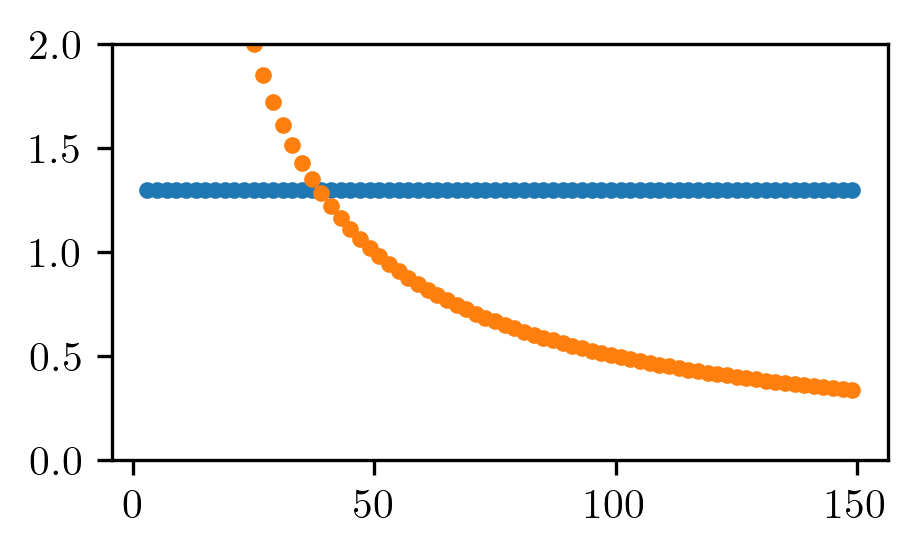

In [104]:
overlap = 0.075*NN / 1
plt.plot(NN, c_opt, "C0.")
plt.plot(NN, 50/(NN), "C1.")
plt.ylim(0, 2)